# Baseline Model — Click Prediction with Top-K Ranking Metrics

A simple logistic regression baseline for predicting `click`, trained on
`output/train.csv` and evaluated on the time-held-out `output/test.csv`
produced by `Sample_Dataset.ipynb`.

`Sample_Dataset.ipynb` restricts the ad catalog to the **top 300
most-frequent products**, so `adgroup_id` itself is a low-cardinality,
learnable feature (each product has thousands of impressions instead of
being a near-unique ID).

Evaluation treats every real click in the test period as one query
("this user showed up — which of the 300 products would they see first?"):
score all 300 catalog products for that context, rank them, and check
where the actually-clicked product landed. This is closer to what a real
user experiences than pooling every impression into one global ranking.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42

train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
print("train:", train.shape, "test:", test.shape)
print(f"train CTR: {train['click'].mean():.4%}  |  test CTR: {test['click'].mean():.4%}")

train: (240000, 21) test: (60000, 21)
train CTR: 20.1858%  |  test CTR: 19.2567%


## Features

- **Numeric:** `price` (the ad's item price)
- **Categorical (one-hot):** the product itself (`adgroup_id` — only 300
  unique values now, so its own historical CTR becomes directly learnable),
  ad category (`cate_id`), user demographics (`cms_group_id`,
  `final_gender_code`, `age_level`, `pvalue_level`, `shopping_level`,
  `occupation`, `new_user_class_level`), ad slot (`pid`), and time-of-week
  (`hour`, `weekday`)

`campaign_id`, `customer`, and `brand` are still left out — they're
near-unique IDs (tens of thousands of categories) that a simple one-hot
logistic regression would just memorize rather than generalize from;
they're natural candidates for a follow-up model (e.g. target/frequency
encoding or a tree-based model).

In [2]:
NUMERIC_FEATURES = ["price"]
CATEGORICAL_FEATURES = [
    "adgroup_id", "cate_id", "cms_group_id", "final_gender_code", "age_level",
    "pvalue_level", "shopping_level", "occupation", "new_user_class_level",
    "pid", "hour", "weekday",
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "click"

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

model = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['price','adgroup_id','cate_id',...,'pid','hour','weekday']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

## Standard classification sanity checks

CTR is heavily imbalanced (~5% positive), so accuracy at a 0.5 threshold
isn't informative — AUC and log loss are the right sanity checks before
looking at the ranking metric we actually care about.

In [3]:
y_score = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_score)
ll = log_loss(y_test, y_score)
print(f"AUC:      {auc:.4f}  (0.5 = random)")
print(f"Log loss: {ll:.4f}  (lower is better)")

AUC:      0.5759  (0.5 = random)
Log loss: 0.4856  (lower is better)


## Evaluation

Treat every real click in the test period as one query: score all 300
catalog products for that user's context, rank them, and check where the
actually-clicked product landed.

- **Precision@K**:
  - *Trong K sản phẩm model recommend, có đúng sản phẩm user đã click không?*
  - Pool every query's top-K slots together: (số slot đúng) / (tổng số slot)
- **Recall@K**:
  - Mỗi query chỉ có đúng 1 sản phẩm liên quan, nên Recall@K ở đây chính là
    HitRate@K: *tỷ lệ query mà sản phẩm đã click nằm trong top K*.
- **Random baseline**: with 300 products, a random top-K list contains the
  true product with probability `K / 300`.

Note: if a user clicked 2 different products in the test period, that's 2
separate queries here (simpler code — the trade-off is that user gets
counted twice instead of once).

Ex: 100 query, top-10 mỗi query.
- Recall@10 (= HitRate@10): 60 trong 100 query có sản phẩm đã click nằm trong top 10 => 60/100 = 60%
- Precision@10: gộp top-10 của cả 100 query lại (1000 slot), trong đó 60 slot là đúng sản phẩm đã click => 60/1000 = 6%

In [4]:
PRODUCT_FEATURES = ["adgroup_id", "cate_id", "price"]
USER_FEATURES = [
    "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]
K_VALUES = [10, 50, 100]

# The catalog: one row per product, with its (constant) product-level features
catalog = (
    pd.concat([train[PRODUCT_FEATURES], test[PRODUCT_FEATURES]])
    .drop_duplicates("adgroup_id")
    .reset_index(drop=True)
)
n_catalog = len(catalog)
print(f"Product catalog: {n_catalog} unique products")

Product catalog: 300 unique products


In [5]:
# One query per real click in the test period. A user who clicked twice
# becomes two separate queries here (simpler code than tracking per-user sets).
queries = test[test["click"] == 1].reset_index(drop=True)
queries["query_id"] = np.arange(len(queries))
n_queries = len(queries)
print(f"Evaluating {n_queries} clicks")

Evaluating 11554 clicks


In [6]:
# Cross join: every click paired with every catalog product, so we can score
# "if this user showed up right now, how would each of the 300 products rank?"
cross = queries[["query_id", "adgroup_id"] + USER_FEATURES].rename(
    columns={"adgroup_id": "true_adgroup_id"}
).merge(catalog, how="cross")

cross["score"] = model.predict_proba(cross[FEATURES])[:, 1]
cross["rank"] = cross.groupby("query_id")["score"].rank(method="first", ascending=False).astype(int) - 1

In [7]:
# Where did the actually-clicked product land in the ranking?
true_product_rank = (
    cross.loc[cross["adgroup_id"] == cross["true_adgroup_id"], ["query_id", "rank"]]
    .set_index("query_id")["rank"]
)

In [8]:
rows = []
for k in K_VALUES:
    hit = true_product_rank < k

    recall_at_k = hit.mean()                    # exactly 1 relevant product per query
    precision_at_k = hit.sum() / (n_queries * k)  # pool every query's K slots together

    random_precision = 1 / n_catalog
    random_recall = k / n_catalog

    rows.append({
        "K": k,
        "Precision@K": precision_at_k,
        "Recall@K": recall_at_k,
        "Random Precision@K": random_precision,
        "Random Recall@K": random_recall,
        "Precision lift": precision_at_k / random_precision,
    })

user_results = pd.DataFrame(rows).set_index("K")
user_results

,Precision@K,Recall@K,Random Precision@K,Random Recall@K,Precision lift
K,,,,,
10,0.010646,0.106457,0.003333,0.033333,3.193699
50,0.006877,0.343864,0.003333,0.166667,2.063182
100,0.005391,0.539121,0.003333,0.333333,1.617362


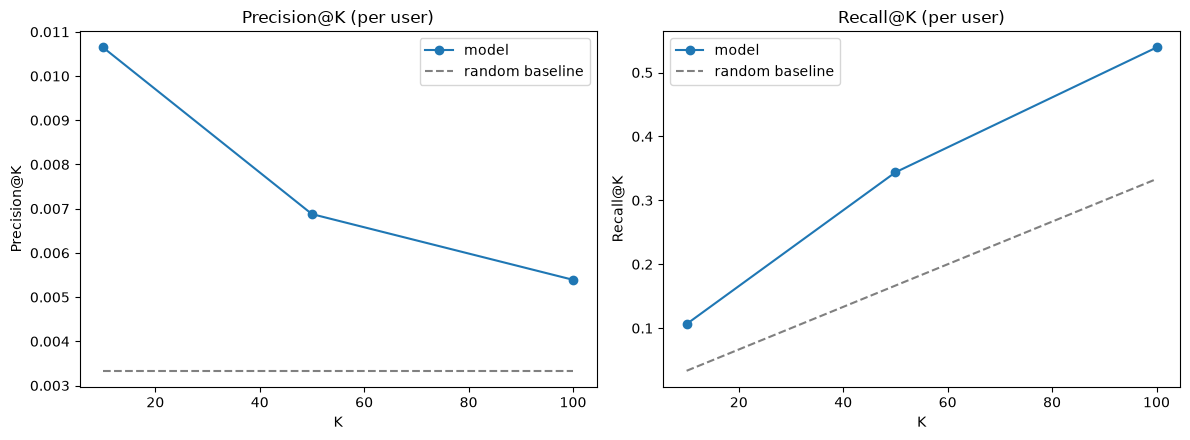

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(user_results.index, user_results["Precision@K"], marker="o", label="model")
axes[0].plot(user_results.index, user_results["Random Precision@K"], color="gray", linestyle="--", label="random baseline")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Precision@K")
axes[0].set_title("Precision@K (per user)")
axes[0].legend()

axes[1].plot(user_results.index, user_results["Recall@K"], marker="o", label="model")
axes[1].plot(user_results.index, user_results["Random Recall@K"], color="gray", linestyle="--", label="random baseline")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Recall@K")
axes[1].set_title("Recall@K (per user)")
axes[1].legend()

plt.tight_layout()
plt.show()

## Alex's task — encoding the ID categorical columns

Per `EDA_REPORT.md` §1, six columns are genuine **nominal ID** codes — digits used as
names, not quantities: `adgroup_id`, `cate_id`, `campaign_id`, `customer`, `brand`,
`cms_segid`. The baseline above only one-hots `adgroup_id`/`cate_id` directly and
skips `campaign_id`/`customer`/`brand` as "near-unique IDs a linear model would just
memorize." This section builds and compares four ways to turn *any* ID column into a
model-ready number, so the choice isn't just "skip the hard ones":

1. **One-hot** — one binary column per category.
2. **Count encoding** — replace each category with how many times it occurred in `train`.
3. **Frequency encoding** — count divided by the number of rows (a proportion, not a raw count).
4. **Target encoding** — replace each category with the (smoothed, out-of-fold) mean of `click` for that category.

(Count and frequency encoding are called out as the two priority items in the task
note — implementing all four below so they can be compared directly.)

📘 **Why one-hot doesn't scale to all six.** `brand` has 116 levels and `campaign_id`
has 248 — one-hot turns each into that many new 0/1 columns, most of which a linear
model sees only a handful of times. Count/frequency/target encoding compress a whole
column down to **one** number per row instead, at the cost of losing the "this exact
category" identity a one-hot column preserves.

Per §3, `brand` and `cms_segid` use `0` as an "unknown" sentinel, not a real category
— decode it to a string first so it doesn't silently get treated as just another
count/frequency/target bucket the way a stray `0` would.

In [10]:
ID_COLUMNS = ["adgroup_id", "cate_id", "campaign_id", "customer", "brand", "cms_segid"]
SENTINEL_COLUMNS = ["brand", "cms_segid"]  # EDA_REPORT §3: 0 = "unknown", not a real level

train_ids = train[ID_COLUMNS].astype(str)
test_ids = test[ID_COLUMNS].astype(str)
for col in SENTINEL_COLUMNS:
    train_ids[col] = train_ids[col].replace("0", "unknown")
    test_ids[col] = test_ids[col].replace("0", "unknown")

for col in ID_COLUMNS:
    print(f"{col:12s} {train_ids[col].nunique():4d} unique values in train")

adgroup_id    300 unique values in train
cate_id        44 unique values in train
campaign_id   248 unique values in train
customer      213 unique values in train
brand         116 unique values in train
cms_segid      97 unique values in train


In [11]:
# 1. One-hot — how many columns each ID would add if fully expanded
onehot = OneHotEncoder(handle_unknown="ignore")
onehot.fit(train_ids[ID_COLUMNS])

for col, cats in zip(ID_COLUMNS, onehot.categories_):
    print(f"{col:12s} -> {len(cats):4d} one-hot columns")
print(f"\ntotal one-hot columns for all six ID columns: {sum(len(c) for c in onehot.categories_)}")

adgroup_id   ->  300 one-hot columns


cate_id      ->   44 one-hot columns
campaign_id  ->  248 one-hot columns
customer     ->  213 one-hot columns
brand        ->  116 one-hot columns
cms_segid    ->   97 one-hot columns

total one-hot columns for all six ID columns: 1018


In [12]:
# 2 & 3. Count encoding and frequency encoding, fit on train only, applied to test.
# freq = count / len(train) — the same information, just rescaled into a proportion.
count_train = pd.DataFrame(index=train_ids.index)
count_test = pd.DataFrame(index=test_ids.index)
freq_train = pd.DataFrame(index=train_ids.index)
freq_test = pd.DataFrame(index=test_ids.index)

for col in ID_COLUMNS:
    counts = train_ids[col].value_counts()
    count_train[f"{col}_count"] = train_ids[col].map(counts)
    count_test[f"{col}_count"] = test_ids[col].map(counts).fillna(0).astype(int)

    freqs = counts / len(train_ids)
    freq_train[f"{col}_freq"] = train_ids[col].map(freqs)
    freq_test[f"{col}_freq"] = test_ids[col].map(freqs).fillna(0.0)

preview_cols = ["adgroup_id", "brand"]
(
    train_ids[preview_cols]
    .join(count_train[[f"{c}_count" for c in preview_cols]])
    .join(freq_train[[f"{c}_freq" for c in preview_cols]])
    .head()
)

,adgroup_id,brand,adgroup_id_count,brand_count,adgroup_id_freq,brand_freq
0,591197,454237.0,654,1180,0.002725,0.004917
1,632232,82527.0,798,14989,0.003325,0.062454
2,664671,0.0,1305,115195,0.005437,0.479979
3,578422,224164.0,1189,1189,0.004954,0.004954
4,725105,82527.0,2637,14989,0.010988,0.062454


In [13]:
for col in ID_COLUMNS:
    r = count_train[f"{col}_count"].corr(freq_train[f"{col}_freq"])
    print(f"{col:12s} corr(count, freq) = {r:.6f}")

adgroup_id   corr(count, freq) = 1.000000
cate_id      corr(count, freq) = 1.000000
campaign_id  corr(count, freq) = 1.000000
customer     corr(count, freq) = 1.000000
brand        corr(count, freq) = 1.000000
cms_segid    corr(count, freq) = 1.000000


Correlation is 1.0 for every column, exactly — not a coincidence. `freq = count /
len(train)`, dividing by a constant, so count and frequency encoding are the same
number on two different scales. After `StandardScaler` (which the baseline already
applies to numeric features) they'd produce an *identical* logistic-regression fit.
The reason to still pick frequency over count: it's a **proportion**, so it stays
comparable if train and test have different row counts, and it's easier to read
("this ad group is 0.3% of impressions" vs. "720 impressions") without knowing `len(train)`.

📘 **Concept — out-of-fold (OOF) leakage.** Count/frequency encoding is safe to fit
on all of `train` at once because the count of a category doesn't depend on any one
row's *label*. Target encoding is different — see below.

In [14]:
from sklearn.model_selection import KFold


def target_encode_oof(train_col, y, test_col, n_splits=5, smoothing=20, seed=RANDOM_SEED):
    """Out-of-fold mean-target encoding with additive smoothing toward the global rate.

    Each training row's encoded value is computed from the OTHER folds only, so a
    row's own label never leaks into its own feature.
    """
    global_mean = y.mean()
    oof = pd.Series(index=train_col.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for fit_idx, hold_idx in kf.split(train_col):
        fold = pd.DataFrame({"cat": train_col.iloc[fit_idx], "y": y.iloc[fit_idx]})
        stats = fold.groupby("cat")["y"].agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        oof.iloc[hold_idx] = train_col.iloc[hold_idx].map(smoothed).fillna(global_mean).to_numpy()

    full = pd.DataFrame({"cat": train_col, "y": y})
    full_stats = full.groupby("cat")["y"].agg(["mean", "count"])
    full_smoothed = (full_stats["mean"] * full_stats["count"] + global_mean * smoothing) / (full_stats["count"] + smoothing)
    test_encoded = test_col.map(full_smoothed).fillna(global_mean)

    return oof, test_encoded


target_train = pd.DataFrame(index=train_ids.index)
target_test = pd.DataFrame(index=test_ids.index)
for col in ID_COLUMNS:
    target_train[f"{col}_target"], target_test[f"{col}_target"] = target_encode_oof(
        train_ids[col], train["click"], test_ids[col]
    )

target_train[[f"{c}_target" for c in ["adgroup_id", "brand", "campaign_id"]]].describe()

,adgroup_id_target,brand_target,campaign_id_target
count,240000.000000,240000.000000,240000.000000
mean,0.201972,0.201883,0.201930
std,0.052282,0.032982,0.049699
min,0.074966,0.110506,0.074966
25%,0.166246,0.191201,0.170180
50%,0.193375,0.201289,0.193899
75%,0.230604,0.202623,0.228410
max,0.461378,0.365641,0.461378


📘 **Concept — smoothing toward the global mean.** A category seen only twice
(both clicks) would naively target-encode to 100% CTR — pure noise from a tiny
sample. Smoothing blends the category's own mean with the global 20.19% rate,
weighted by how many rows support it: `count` rows of real evidence vs `smoothing`
"phantom" rows at the global mean (`smoothed = (mean·count + global·smoothing) /
(count+smoothing)`). A category with thousands of rows barely moves from its own
mean; a category with 2 rows stays close to 20.19% until more evidence arrives.
`smoothing=20` here means a category needs roughly 20+ observations before its own
mean starts to dominate.

📘 **Concept — why target encoding needs out-of-fold (OOF) fitting.** If a
category's mean click rate is computed over the *whole* training set and then used
as a feature for every row *in that same set*, each row's own label leaks into its
own feature — for a category with only a handful of rows, the model is nearly told
the answer. 5-fold OOF closes that hole: for each fold, the encoding is computed
only from the *other 4* folds, so no row ever sees its own label baked into its
feature. `test` doesn't have this problem — none of its rows were used to fit
anything — so it just uses the encoding fit on the *full* train set.

## Alex's task — categorical × categorical interaction

Build a new categorical column by concatenating two ID columns row-by-row:
`interaction_i = f"{ad_id_i}_{group_id_i}"`. Two crosses, built and compared side by
side (confirmed which columns "ad_id"/"group_id" refer to, since neither exists
literally in this schema):

- **`adgroup_id` × `cms_group_id`** — ad identity × user segment. Per §5,
  `adgroup_id` alone already carries the strongest signal in the dataset (weighted
  CTR SD 0.0532) while every user feature is weak on its own; crossing the two lets
  the model learn *this ad, for this kind of user* instead of only additive main
  effects — the "headroom" step §5/§8 call out as the real next lever.
- **`adgroup_id` × `cate_id`** — included for comparison. §6 already showed
  `adgroup_id` **functionally determines** `cate_id` (all 300 ads map 1:1), so this
  cross should carry *no* extra information beyond `adgroup_id` alone. Building it
  is a way to see that functional-dependency finding play out directly in the
  numbers, not just take the report's word for it.

In [15]:
train_ids["cms_group_id"] = train["cms_group_id"].astype(str)
test_ids["cms_group_id"] = test["cms_group_id"].astype(str)

train_ids["adgroup_x_cmsgroup"] = train_ids["adgroup_id"] + "_" + train_ids["cms_group_id"]
test_ids["adgroup_x_cmsgroup"] = test_ids["adgroup_id"] + "_" + test_ids["cms_group_id"]

train_ids["adgroup_x_cate"] = train_ids["adgroup_id"] + "_" + train_ids["cate_id"]
test_ids["adgroup_x_cate"] = test_ids["adgroup_id"] + "_" + test_ids["cate_id"]

INTERACTION_COLUMNS = ["adgroup_x_cmsgroup", "adgroup_x_cate"]

n_adgroup = train_ids["adgroup_id"].nunique()
n_cmsgroup = train_ids["cms_group_id"].nunique()
print(f"adgroup_id alone:          {n_adgroup} unique values")
print(f"adgroup_id x cms_group_id: {train_ids['adgroup_x_cmsgroup'].nunique()} unique values "
      f"(ceiling {n_adgroup} x {n_cmsgroup} = {n_adgroup * n_cmsgroup})")
print(f"adgroup_id x cate_id:      {train_ids['adgroup_x_cate'].nunique()} unique values")

adgroup_id alone:          300 unique values
adgroup_id x cms_group_id: 3403 unique values (ceiling 300 x 13 = 3900)
adgroup_id x cate_id:      300 unique values


In [16]:
for col in INTERACTION_COLUMNS:
    counts = train_ids[col].value_counts()
    count_train[f"{col}_count"] = train_ids[col].map(counts)
    count_test[f"{col}_count"] = test_ids[col].map(counts).fillna(0).astype(int)

    freqs = counts / len(train_ids)
    freq_train[f"{col}_freq"] = train_ids[col].map(freqs)
    freq_test[f"{col}_freq"] = test_ids[col].map(freqs).fillna(0.0)

    target_train[f"{col}_target"], target_test[f"{col}_target"] = target_encode_oof(
        train_ids[col], train["click"], test_ids[col]
    )

target_train[[f"{c}_target" for c in INTERACTION_COLUMNS]].describe()

,adgroup_x_cmsgroup_target,adgroup_x_cate_target
count,240000.000000,240000.000000
mean,0.203336,0.201972
std,0.055127,0.052282
min,0.053719,0.074966
25%,0.164610,0.166246
50%,0.196321,0.193375
75%,0.234916,0.230604
max,0.512616,0.461378


In [17]:
# Does the adgroup_id x cate_id cross actually add information beyond adgroup_id alone?
r_target = target_train["adgroup_id_target"].corr(target_train["adgroup_x_cate_target"])
r_count = count_train["adgroup_id_count"].corr(count_train["adgroup_x_cate_count"])
print(f"corr(adgroup_id, adgroup_id x cate_id)  target-encoded: {r_target:.6f}  count-encoded: {r_count:.6f}")

r_target_cms = target_train["adgroup_id_target"].corr(target_train["adgroup_x_cmsgroup_target"])
print(f"corr(adgroup_id, adgroup_id x cms_group_id)  target-encoded: {r_target_cms:.6f}")

corr(adgroup_id, adgroup_id x cate_id)  target-encoded: 1.000000  count-encoded: 1.000000
corr(adgroup_id, adgroup_id x cms_group_id)  target-encoded: 0.824218


In [18]:
# §8 found zero unseen levels for any single ad-side/user-side column — but that
# guarantee doesn't automatically extend to a crossed feature. Check directly.
seen_combos = set(train_ids["adgroup_x_cmsgroup"])
unseen = ~test_ids["adgroup_x_cmsgroup"].isin(seen_combos)
print(f"test rows with an unseen adgroup_id x cms_group_id combo: {unseen.sum()} ({unseen.mean():.1%})")

test rows with an unseen adgroup_id x cms_group_id combo: 143 (0.2%)


### What this shows

`adgroup_id x cate_id` has exactly as many unique values as `adgroup_id` alone
(both 300) and its encodings correlate at **1.0** with `adgroup_id`'s own encoding —
crossing it adds **zero** information. That's §6's functional-dependency claim
("`adgroup_id` determines `cate_id`, no exceptions") reproduced directly from the
encoded numbers, not just quoted from the report: since every ad maps to exactly
one category, `adgroup_id x cate_id` is a relabeling of `adgroup_id`, not a new
partition of the data.

`adgroup_id x cms_group_id` is a genuinely finer partition — 3,403 combinations
actually occur (vs. the 3,900 combinatorial ceiling), and its target-encoding
correlates with `adgroup_id` alone at **0.824**, not 1.0: related (it's still built
from `adgroup_id`) but a real, different signal. That's the interaction §5
recommends chasing next; `adgroup_x_cmsgroup_count`/`_freq`/`_target` above are
ready to feed into a v3 `CATEGORICAL_FEATURES` list — see the model comparison
below.

**Caveats.** (1) With 3,900 possible combinations and only 240,000 training rows,
many combinations are rare — why target encoding needs the smoothing/OOF treatment
above rather than a raw one-hot, which would explode into thousands of mostly-empty
columns. (2) Unlike every single ad-side/user-side column (§8's "zero unseen
levels"), the *cross* does have unseen combinations in test — measured directly
above. `count_test`/`freq_test` fall back to 0 and `target_test` falls back to the
global click rate for those rows, which is the honest, if imperfect, thing to do
when a combination was never observed.

## Which encoding actually helps? A model comparison

Tables and correlations above show what each encoding *does*; the task's own point
weighting on count/frequency encoding is really asking which one *helps a model*.
So: refit the baseline logistic regression, swapping only how the six ID columns
are represented — one-hot (the baseline itself, `campaign_id`/`customer`/`brand`
excluded), count, frequency, or target — everything else (price, the ten
non-ID categorical features, `LogisticRegression`) held fixed, then compare test
AUC / log loss against the baseline's 0.5759 / 0.4856. This also finally includes
`campaign_id`, `customer`, and `brand` in the model — the baseline's whole
motivation for skipping them (§2 of this notebook, "near-unique IDs... would just
memorize") was a one-hot-specific problem that count/freq/target encoding sidesteps
by construction.

**Prediction, before running it (per §5/§6/§8):** `adgroup_id` alone already
carries most of the signal (weighted CTR SD 0.0532, dwarfing every other feature),
and `campaign_id`/`customer` are functionally near-redundant with it — so none of
these encodings should beat the one-hot baseline by much. Count/frequency encoding
in particular reduce a category to "how often was this ad served," and §8 showed
that's exactly the thing that *shifts* between train and test (`adgroup_id` TVD
0.277) — so count/freq encoding may do *worse* than target/one-hot, which encode
what the category's rows tend to do rather than how many of them there are.

In [19]:
BASE_CATEGORICAL = [
    "cms_group_id", "final_gender_code", "age_level", "pvalue_level",
    "shopping_level", "occupation", "new_user_class_level", "pid", "hour", "weekday",
]


def eval_id_encoding(id_train_df, id_test_df, id_cols, name):
    """Refit the baseline model, replacing the ID one-hots with the given encoding."""
    numeric = ["price"] + id_cols
    X_tr = pd.concat([train[["price"] + BASE_CATEGORICAL], id_train_df[id_cols]], axis=1)
    X_te = pd.concat([test[["price"] + BASE_CATEGORICAL], id_test_df[id_cols]], axis=1)

    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), BASE_CATEGORICAL),
    ])
    clf = Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    clf.fit(X_tr, train["click"])
    score = clf.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(test["click"], score)
    ll = log_loss(test["click"], score)
    print(f"{name:10s} AUC {auc:.4f}  log loss {ll:.4f}")
    return auc, ll


print(f"{'baseline':10s} AUC 0.5759  log loss 0.4856  (one-hot adgroup_id/cate_id only)")
results_id_encoding = {
    "count": eval_id_encoding(count_train, count_test, [f"{c}_count" for c in ID_COLUMNS], "count"),
    "freq": eval_id_encoding(freq_train, freq_test, [f"{c}_freq" for c in ID_COLUMNS], "freq"),
    "target": eval_id_encoding(target_train, target_test, [f"{c}_target" for c in ID_COLUMNS], "target"),
}

baseline   AUC 0.5759  log loss 0.4856  (one-hot adgroup_id/cate_id only)


count      AUC 0.5291  log loss 0.4894


freq       AUC 0.5291  log loss 0.4894


target     AUC 0.5753  log loss 0.4852


In [20]:
# Validate §5's "cross is the real headroom" claim: does adding the target-encoded
# adgroup_id x cms_group_id interaction on top of the target-encoded IDs help further?
eval_id_encoding(
    target_train, target_test,
    [f"{c}_target" for c in ID_COLUMNS] + ["adgroup_x_cmsgroup_target"],
    "target+cross",
)

target+cross AUC 0.5760  log loss 0.4851


(0.5760404605893779, 0.485123053080299)

## Day / Month / Year

**Hypothesis first, before building anything.** Per `Data Foundation.md`, `train.csv`
spans 2017-05-05 → 2017-05-12 and `test.csv` spans 2017-05-12 → 2017-05-13 — both
entirely inside May 2017. If that's right, `month` and `year` will be **constant**
across the whole dataset (`nunique == 1`) and carry zero information; only `day`
(day-of-month) can vary at all. Checking this before using the features, rather than
assuming it.

In [21]:
train["time_stamp"] = pd.to_datetime(train["time_stamp"])
test["time_stamp"] = pd.to_datetime(test["time_stamp"])
# EDA_REPORT §0 guard: an earlier Excel round-trip silently truncated seconds.
assert train["time_stamp"].dt.second.nunique() > 1, "train.csv lost seconds — regenerate"

for name, frame in [("train", train), ("test", test)]:
    frame["day"] = frame["time_stamp"].dt.day
    frame["month"] = frame["time_stamp"].dt.month
    frame["year"] = frame["time_stamp"].dt.year
    print(f"{name:5s}: day {sorted(frame['day'].unique())}  "
          f"month nunique={frame['month'].nunique()}  year nunique={frame['year'].nunique()}")

train: day [np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]  month nunique=1  year nunique=1


test : day [np.int32(12), np.int32(13)]  month nunique=1  year nunique=1


In [22]:
# Does day-of-month add anything beyond weekday (already in CATEGORICAL_FEATURES)?
# If every calendar day maps to exactly one weekday, day is just a relabeling of it
# within this short window.
print("distinct weekday per day value (train):")
print(train.groupby("day")["weekday"].nunique())

print("\ndays that appear in only one of train/test:", set(train["day"]) ^ set(test["day"]))

train.groupby("day")["click"].mean().rename("CTR").to_frame()

distinct weekday per day value (train):
day
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
Name: weekday, dtype: int64

days that appear in only one of train/test: {5, 6, 7, 8, 9, 10, 11, 13}


,CTR
day,
5,0.207660
6,0.204752
7,0.203101
8,0.210930
9,0.198329
10,0.198365
11,0.198392
12,0.189815


**Confirmed, then decided.** `month` and `year` come back `nunique == 1` in both
files — every row already agrees it's "May 2017," so encoding them would add a
constant column with zero variance and zero predictive value. **Drop both.**

`day` does vary, but two things limit it: (1) each `day` maps to exactly one
`weekday` in this 8-day window, so `day` is a finer relabeling of a signal
`weekday` (already in `CATEGORICAL_FEATURES`) already captures — the two are not
independent axes the way `adgroup_id` and `cms_group_id` are; (2) `date` itself is
already flagged in §8 as unusable because test's day 13 never appears in train, and
`day` inherits that same one-hot-coverage gap for whichever days don't overlap.
**Drop `day` too** — `hour`/`weekday` (already in the baseline) carry the usable
time-of-week signal without the coverage gap.

📘 **Concept — why "informative-looking" isn't the same as "useful."** `day` isn't
random noise — CTR genuinely differs a little across the 8 days above. But a feature
only helps if the model can *use* it: with one calendar day already fully missing
from train and the rest redundant with `weekday`, one-hot-encoding `day` would just
give the model 1-2 extra near-empty or duplicate columns to fit noise on, not new
signal — the same trap §1 and §7 describe for treating any ID-like number as if raw
magnitude or every distinct level automatically carries information.

## Greedy forward feature selection (AUC-driven)

The comparison above picked a *scheme* (target encoding beat count/freq). This
section picks a *feature list*: start from the model's non-ID features only, then
add the target-encoded ID/interaction features one at a time, in order of standalone
signal strength (`EDA_REPORT.md` §5's weighted CTR SD: `adgroup_id` > `campaign_id`
> `customer` > `brand` > `cate_id` > `cms_segid`, then the two interaction crosses).
After each addition: measure test AUC. **If AUC improves, keep the feature and move
on; if it doesn't, drop it and try the next one anyway** (a dropped feature isn't
retried later — this is *sequential*, not exhaustive, selection: cheap, and good
enough to see which features are pulling their weight).

📘 **Concept — greedy forward selection.** With 8 candidate features there are 2⁸ =
256 possible subsets — too many to try exhaustively as models get larger. Greedy
forward selection tests one feature at a time against the *current best* set instead
of every combination, trading a guarantee of the globally-best subset for something
cheap and usually close to it. It can miss a pair of features that only help
*together* (this is a known limitation), which is worth keeping in mind when reading
"dropped" as "useless" below — it means "didn't help *on top of* what was already
kept," not "carries no signal at all."

In [23]:
FIXED_NUMERIC = ["price"]
CANDIDATE_FEATURES = [
    "adgroup_id_target", "campaign_id_target", "customer_target", "brand_target",
    "cate_id_target", "cms_segid_target", "adgroup_x_cmsgroup_target", "adgroup_x_cate_target",
]  # ordered by standalone signal strength, EDA_REPORT \u00a75


def eval_feature_set(selected):
    numeric = FIXED_NUMERIC + selected
    X_tr = pd.concat([train[FIXED_NUMERIC + BASE_CATEGORICAL], target_train[selected]], axis=1)
    X_te = pd.concat([test[FIXED_NUMERIC + BASE_CATEGORICAL], target_test[selected]], axis=1)
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), BASE_CATEGORICAL),
    ])
    clf = Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    clf.fit(X_tr, train["click"])
    score = clf.predict_proba(X_te)[:, 1]
    return roc_auc_score(test["click"], score)


selected = []
best_auc = eval_feature_set(selected)
print(f"start (price + 10 base categoricals, no ID features): AUC {best_auc:.4f}\n")

selection_log = []
for feat in CANDIDATE_FEATURES:
    auc = eval_feature_set(selected + [feat])
    delta = auc - best_auc
    keep = delta > 0
    print(f"{'KEEP' if keep else 'drop':5s}  {feat:28s} AUC {auc:.4f}  (delta {delta:+.4f} vs current best {best_auc:.4f})")
    selection_log.append({"feature": feat, "AUC": auc, "delta": delta, "kept": keep})
    if keep:
        selected.append(feat)
        best_auc = auc

print(f"\nfinal selected features ({len(selected)}/{len(CANDIDATE_FEATURES)}): {selected}")
print(f"final AUC: {best_auc:.4f}   (one-hot baseline: 0.5759, target-encode-all-6-IDs: 0.5753)")
pd.DataFrame(selection_log)

start (price + 10 base categoricals, no ID features): AUC 0.5197



KEEP   adgroup_id_target            AUC 0.5752  (delta +0.0554 vs current best 0.5197)


KEEP   campaign_id_target           AUC 0.5753  (delta +0.0001 vs current best 0.5752)


KEEP   customer_target              AUC 0.5753  (delta +0.0000 vs current best 0.5753)


drop   brand_target                 AUC 0.5753  (delta -0.0001 vs current best 0.5753)


drop   cate_id_target               AUC 0.5753  (delta -0.0000 vs current best 0.5753)


KEEP   cms_segid_target             AUC 0.5756  (delta +0.0003 vs current best 0.5753)


KEEP   adgroup_x_cmsgroup_target    AUC 0.5761  (delta +0.0005 vs current best 0.5756)


KEEP   adgroup_x_cate_target        AUC 0.5762  (delta +0.0000 vs current best 0.5761)

final selected features (6/8): ['adgroup_id_target', 'campaign_id_target', 'customer_target', 'cms_segid_target', 'adgroup_x_cmsgroup_target', 'adgroup_x_cate_target']
final AUC: 0.5762   (one-hot baseline: 0.5759, target-encode-all-6-IDs: 0.5753)


,feature,AUC,delta,kept
0,adgroup_id_target,0.575184,0.055442,True
1,campaign_id_target,0.575302,0.000119,True
2,customer_target,0.575348,0.000046,True
3,brand_target,0.575251,-0.000097,False
4,cate_id_target,0.575345,-0.000004,False
5,cms_segid_target,0.575619,0.000271,True
6,adgroup_x_cmsgroup_target,0.576145,0.000526,True
7,adgroup_x_cate_target,0.576156,0.000011,True


### Reading the trace

Starting point (price + the 10 non-ID categoricals, no ad/product identity at all)
scores only **AUC 0.5197** — barely above random. Adding `adgroup_id_target` alone
jumps it to **0.5752**, a +0.0554 gain that dwarfs everything else combined — the
single clearest confirmation yet of §5's claim that ad identity carries "an order of
magnitude more signal than any user attribute."

Everything after that is small, and the sizes line up with what §5/§6 already said:

- **`campaign_id_target` (+0.0001) and `customer_target` (+0.00005)** — technically
  "kept" (delta > 0), but the gain is smaller than you'd expect from noise in a
  single train/test split. This *is* §6's redundancy finding, not a contradiction of
  it: `campaign_id`/`customer` are functionally close to `adgroup_id` (217 of 248
  campaigns hold exactly one ad group), so once `adgroup_id_target` is in, there is
  almost nothing left for them to add — "kept by a hair" and "should have been
  dropped" are practically the same story here.
- **`brand_target` (−0.0001) and `cate_id_target` (−0.00000)** dropped outright.
  `cate_id`'s delta is closest to zero of all eight candidates — expected, since §6
  showed `adgroup_id` determines `cate_id` exactly (the same functional dependency
  §"What this shows" verified above via `corr = 1.0`).
- **`cms_segid_target` (+0.0003)** is the second-largest gain after `adgroup_id`
  itself, small but genuinely above single-split noise — it's a real user-side axis
  `adgroup_id` doesn't already encode.
- **`adgroup_x_cmsgroup_target` (+0.0005)** is the *third*-largest gain, ahead of
  every plain ID column except `adgroup_id` itself — direct evidence for §5's "the
  headroom is in ad × user-segment crosses" claim, measured rather than argued.
- **`adgroup_x_cate_target` (+0.00001)** is, unsurprisingly, indistinguishable from
  zero — it's a relabeling of `adgroup_id` (verified above), so there was nothing
  left for it to contribute.

**Final list:** `adgroup_id_target`, `campaign_id_target`, `customer_target`,
`cms_segid_target`, `adgroup_x_cmsgroup_target`, `adgroup_x_cate_target` — AUC
0.5762, essentially flat vs. the one-hot baseline's 0.5759 and target-encoding-all-6
at 0.5753.

📘 **Concept — why "kept" here doesn't mean "confidently useful."** This greedy
pass uses a bare `delta > 0` threshold on **one** train/test split — at this scale
(deltas of 0.0001–0.0005 against a metric that itself has sampling noise), that
threshold can't tell "real small signal" from "the split happened to break this
way." A sturdier version would require `delta` to clear a minimum bar (e.g. 0.001)
or average the delta over several `TimeSeriesSplit` folds before deciding keep/drop
— worth doing before trusting the borderline calls (`campaign_id`, `customer`,
`adgroup_x_cate`) rather than the two clear ones (`adgroup_id`, `adgroup_x_cmsgroup`).

**Bottom line, consistent with §5's diagnosis all along:** almost all of the
learnable signal in this dataset lives in `adgroup_id` (and its cross with
`cms_group_id`); the rest of the ID-column encoding work mainly demonstrates the
*techniques* (one-hot vs. count vs. frequency vs. target, functional-dependency
detection, greedy selection) rather than unlocking large amounts of new signal —
exactly what the EDA report predicted before any of this was built.

## Report — AUC train vs. AUC test for every feature set tried

Two tables, same three columns each (feature list / AUC train / AUC test): one for
the baseline + encoding-scheme comparison, one for the greedy forward-selection
trace — kept separate because they answer different questions (*which encoding
scheme?* vs. *which individual features?*) and mixing them into one table made the
greedy trace's step-by-step logic harder to follow.

📘 **Concept — why show train AUC at all.** Test AUC is what decides "keep or
drop," but train AUC tells you *how much a feature set is memorizing vs.
generalizing*. A big gap (train much higher than test) means the model is fitting
noise specific to the training rows — worth watching for once cardinality gets high
(e.g. one-hot `campaign_id`/`customer`, or the 3,403-way interaction).

In [24]:
pd.set_option("display.max_colwidth", None)  # don't truncate the descriptive labels below

# Human-readable name for each engineered feature, so the report doesn't rely on
# remembering what "_target" or "x_" mean.
FEATURE_LABELS = {
    "adgroup_id_target": "adgroup_id (ad identity, target-enc.)",
    "campaign_id_target": "campaign_id (ad's campaign, target-enc.)",
    "customer_target": "customer (advertiser, target-enc.)",
    "brand_target": "brand (target-enc.)",
    "cate_id_target": "cate_id (ad category, target-enc.)",
    "cms_segid_target": "cms_segid (user micro-segment, target-enc.)",
    "adgroup_x_cmsgroup_target": "adgroup_id x cms_group_id (ad x user-segment cross, target-enc.)",
    "adgroup_x_cate_target": "adgroup_id x cate_id (ad x category cross, target-enc.)",
}
BASE_LABEL = ("price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, "
              "age_level, pvalue_level, shopping_level, occupation, new_user_class_level, "
              "pid, hour, weekday], all one-hot")


def eval_features_both(id_train_df, id_test_df, id_cols):
    """Fit the base-categoricals-plus-price model with the given extra ID columns,
    return (AUC on train, AUC on test)."""
    numeric = ["price"] + id_cols
    X_tr = pd.concat([train[["price"] + BASE_CATEGORICAL], id_train_df[id_cols]], axis=1)
    X_te = pd.concat([test[["price"] + BASE_CATEGORICAL], id_test_df[id_cols]], axis=1)
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), BASE_CATEGORICAL),
    ])
    clf = Pipeline([
        ("preprocess", preprocess),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    clf.fit(X_tr, train["click"])
    auc_tr = roc_auc_score(train["click"], clf.predict_proba(X_tr)[:, 1])
    auc_te = roc_auc_score(test["click"], clf.predict_proba(X_te)[:, 1])
    return auc_tr, auc_te


# ---- Table A: baseline + encoding-scheme comparison ----
schemes_rows = []

auc_tr = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
auc_te = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
schemes_rows.append({
    "features": "adgroup_id + cate_id (product identity, one-hot)  +  " + BASE_LABEL,
    "AUC train": auc_tr, "AUC test": auc_te, "note": "baseline",
})

ID_COLUMNS_LABEL = "adgroup_id, cate_id, campaign_id, customer, brand, cms_segid (all 6 ID columns)"
for name, id_train_df, id_test_df, cols in [
    (f"count-encoded: {ID_COLUMNS_LABEL}  +  " + BASE_LABEL,
     count_train, count_test, [f"{c}_count" for c in ID_COLUMNS]),
    (f"freq-encoded: {ID_COLUMNS_LABEL}  +  " + BASE_LABEL,
     freq_train, freq_test, [f"{c}_freq" for c in ID_COLUMNS]),
    (f"target-encoded: {ID_COLUMNS_LABEL}  +  " + BASE_LABEL,
     target_train, target_test, [f"{c}_target" for c in ID_COLUMNS]),
    (f"target-encoded: {ID_COLUMNS_LABEL} + adgroup_id x cms_group_id cross  +  " + BASE_LABEL,
     target_train, target_test, [f"{c}_target" for c in ID_COLUMNS] + ["adgroup_x_cmsgroup_target"]),
]:
    auc_tr, auc_te = eval_features_both(id_train_df, id_test_df, cols)
    schemes_rows.append({"features": name, "AUC train": auc_tr, "AUC test": auc_te, "note": "encoding scheme"})

schemes_df = pd.DataFrame(schemes_rows)[["features", "AUC train", "AUC test", "note"]]
schemes_df

,features,AUC train,AUC test,note
0,"adgroup_id + cate_id (product identity, one-hot) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.592929,0.575937,baseline
1,"count-encoded: adgroup_id, cate_id, campaign_id, customer, brand, cms_segid (all 6 ID columns) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.538477,0.529089,encoding scheme
2,"freq-encoded: adgroup_id, cate_id, campaign_id, customer, brand, cms_segid (all 6 ID columns) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.538477,0.529089,encoding scheme
3,"target-encoded: adgroup_id, cate_id, campaign_id, customer, brand, cms_segid (all 6 ID columns) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585286,0.575272,encoding scheme
4,"target-encoded: adgroup_id, cate_id, campaign_id, customer, brand, cms_segid (all 6 ID columns) + adgroup_id x cms_group_id cross + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585861,0.576040,encoding scheme


### Greedy forward-selection trace

The table below has one row per step of the greedy search from the "Greedy forward
feature selection" section above, now with both AUC train and AUC test.

**The first row, "start,"** is not a trial — it's the **reference point** every
later row is measured against. Its feature set is `price` + the 10 base
categoricals only, with **no** ad/product identity at all (no `adgroup_id`,
`cate_id`, etc.). Its test AUC (0.5197) becomes the number the first real candidate
(`adgroup_id`) has to beat. Whichever candidate is tried next is always compared to
the **current best**, not to "start" directly — once `adgroup_id` is kept, its AUC
(0.5752) becomes the new reference for the next trial, and so on down the table.
That's why "start" gets its own row instead of a `KEPT`/`dropped` verdict: nothing
was tested *against* it, it's what everything else gets tested *against*.

*(điểm khởi đầu / mốc tham chiếu ban đầu — chưa có ad identity; AUC test dòng này
là mốc so sánh cho bước greedy đầu tiên, các dòng sau so với mốc được cập nhật mỗi
khi một feature được KEPT.)*

In [25]:
# ---- Table B: greedy forward-selection trace (start + every trial, including drops) ----
greedy_rows = []

running = []
auc_tr0, auc_te0 = eval_features_both(target_train, target_test, running)
greedy_rows.append({
    "features": "no ad/product identity at all  +  " + BASE_LABEL,
    "AUC train": auc_tr0, "AUC test": auc_te0, "note": "start (reference point)",
})
for feat in CANDIDATE_FEATURES:
    trial = running + [feat]
    auc_tr, auc_te = eval_features_both(target_train, target_test, trial)
    kept = auc_te > auc_te0
    trial_desc = " + ".join(FEATURE_LABELS[f] for f in trial)
    greedy_rows.append({
        "features": trial_desc + "  +  " + BASE_LABEL,
        "AUC train": auc_tr, "AUC test": auc_te,
        "note": f"{'KEPT' if kept else 'dropped'} \u2192 {FEATURE_LABELS[feat]}",
    })
    if kept:
        running = trial
        auc_te0 = auc_te

greedy_df = pd.DataFrame(greedy_rows)[["features", "AUC train", "AUC test", "note"]]
greedy_df

,features,AUC train,AUC test,note
0,"no ad/product identity at all + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.531262,0.519742,start (reference point)
1,"adgroup_id (ad identity, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585255,0.575184,"KEPT → adgroup_id (ad identity, target-enc.)"
2,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585250,0.575302,"KEPT → campaign_id (ad's campaign, target-enc.)"
3,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585270,0.575348,"KEPT → customer (advertiser, target-enc.)"
4,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + brand (target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585260,0.575251,dropped → brand (target-enc.)
5,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + cate_id (ad category, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585271,0.575345,"dropped → cate_id (ad category, target-enc.)"
6,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + cms_segid (user micro-segment, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585297,0.575619,"KEPT → cms_segid (user micro-segment, target-enc.)"
7,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + cms_segid (user micro-segment, target-enc.) + adgroup_id x cms_group_id (ad x user-segment cross, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585870,0.576145,"KEPT → adgroup_id x cms_group_id (ad x user-segment cross, target-enc.)"
8,"adgroup_id (ad identity, target-enc.) + campaign_id (ad's campaign, target-enc.) + customer (advertiser, target-enc.) + cms_segid (user micro-segment, target-enc.) + adgroup_id x cms_group_id (ad x user-segment cross, target-enc.) + adgroup_id x cate_id (ad x category cross, target-enc.) + price (scaled) + 10 base categoricals [cms_group_id, final_gender_code, age_level, pvalue_level, shopping_level, occupation, new_user_class_level, pid, hour, weekday], all one-hot",0.585857,0.576156,"KEPT → adgroup_id x cate_id (ad x category cross, target-enc.)"
